# Notes

Please note that numpy imshow uses the (vertical, horizontal) format, with the vertical axis going from top to bottom and the horizontal from left to right.  
This is currently assumed to be the target output.

# Crop and rotate stimulus files

In [11]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [ ]:
stim_dir = '/gpfs01/euler/data/Resources/StimulusPickle/'
os.listdir(stim_dir)

['bar_time_s.npy',
 'bar_trigger.npy',
 'chirp1000_setup1.npy',
 'chirp1000_setup3.npy',
 'chirp800_setup1.npy',
 'chirp800_setup3.npy',
 'chirp_time_s.npy',
 'chirp_trigger.npy',
 'DS_setup1.npy',
 'DS_setup3.npy',
 'DS_setup3_movie_and_trigger.npz',
 'RGC_MovingBar_setup1.npy',
 'RGC_MovingBar_setup3.npy']

In [5]:
crop_setup1_h = 10  # left and right
crop_setup1_v = 10

In [6]:
crop_setup3_h = 10  # left and right
crop_setup3_v = 10

In [ ]:
out_dir = Path('../exports/All-GCL-collection')

## MB

In [14]:
bar_file = 'RGC_MovingBar_60Hz_10um_pixels.npy'
bar_mark_file = 'RGC_MovingBar_60Hz_10um_pixels_mark.npy'

In [15]:
bar = np.load(os.path.join(stim_dir, bar_file))
bar = np.round(np.mean(bar, axis=-1)).astype(int)
bar.shape

FileNotFoundError: [Errno 2] No such file or directory: '..\\arrays\\All-GCL-collection\\RGC_MovingBar_60Hz_10um_pixels.npy'

In [8]:
bar[2*60, 0, 0]

0

In [9]:
bar_mark = np.load(os.path.join(stim_dir, bar_mark_file))
bar_mark = np.append(bar_mark[:-1] & (~bar_mark[1:]), False)
bar_mark

array([False, False, False, ..., False, False, False])

In [10]:
time_bar = np.arange(bar.shape[0]) * 1./60.

In [22]:
def plot_mb(bar, bar_mark, time_bar):
    fig, axs = plt.subplot_mosaic(
        """
        ABCDE
        FFFFF
        """,
        figsize=(12, 4)
    )
    
    ax = axs['A']
    h, w = bar.shape[1:3]
    im = ax.imshow(np.mean(bar, axis=0), vmin=0, extent=(-w/2, w/2, h/2, -h/2))
    ax.set(xlabel='left <-> right\n[pix=10 µm]', ylabel='front <-> back\n[pix=10 µm]', title='mean')
    plt.colorbar(im, ax=ax)

    all_ts = [4.3, 8.3, 12.3, 16.3]
    
    for i, t_s in enumerate(all_ts):
        ax = axs["BCDE"[i]]
        ax.set_title(f't={t_s}s')
        h, w = bar.shape[1:3]
        im = ax.imshow(bar[int(60*t_s)], vmin=0, vmax=255, extent=(-w/2, w/2, h/2, -h/2))
        plt.colorbar(im, ax=ax, ticks=[0, 255])
    
    ax = axs['F']
    ax.plot(time_bar, bar[:, bar.shape[1] // 2, bar.shape[2] // 2], label='Int. @ Center')
    ax.vlines(time_bar[bar_mark], -70, -20, color='r', label='Trigger')
    ax.vlines(all_ts, ymin=260, ymax=300, color='k', label='Shown frames')
    ax.set_xticks(np.arange(int(max(time_bar))))
    ax.set(xlabel='Time [s]', ylabel='Intensity')
    ax.set_yticks([0, 100, 200, 255])
    ax.legend(loc='lower right')

    for i, deg in enumerate([0, 180, 45, 225, 90, 270, 135, 315]):
        ax.text((4.5+4*i), 260, f"{deg}°", ha='left', va='bottom')

    plt.tight_layout()
    
    return fig, axs

In [23]:
np.sum(bar_mark[:-1])

8

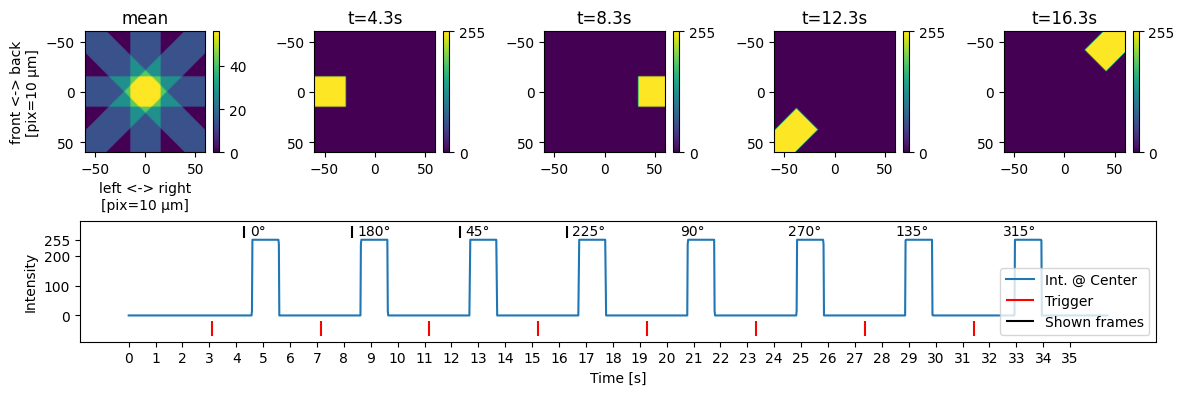

In [24]:
plot_mb(bar, bar_mark, time_bar);

In [17]:
np.save(os.path.join(out_dir, 'bar_trigger'), bar_mark)
np.save(os.path.join(out_dir, 'bar_time_s'), time_bar)

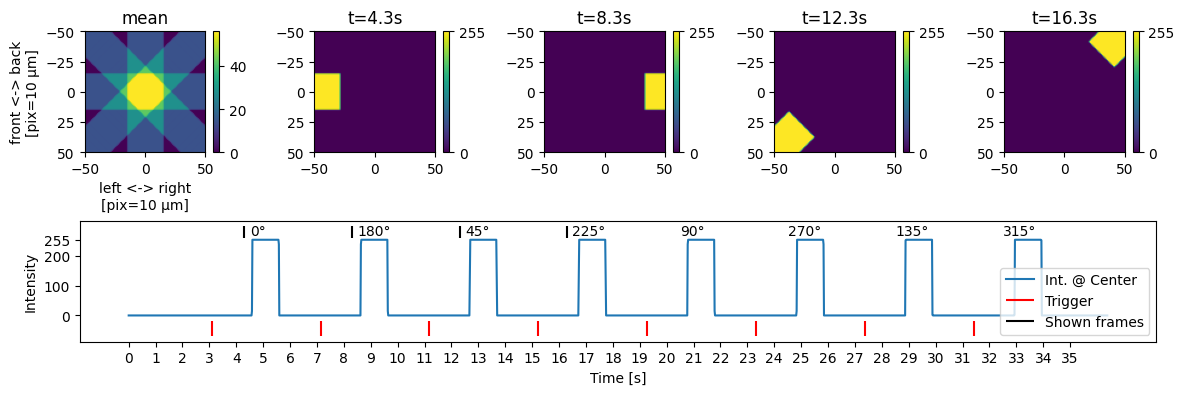

In [27]:
# →, ←, ↗, ↙, ↑, ↓, ↖, ↘
RGC_MovingBar_setup1 = bar[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
fig, axs = plot_mb(RGC_MovingBar_setup1, bar_mark, time_bar)
np.save(os.path.join(out_dir, 'RGC_MovingBar_setup1'), RGC_MovingBar_setup1)
plt.savefig(os.path.join(out_dir, 'RGC_MovingBar_setup1.pdf'), bbox_inches='tight')

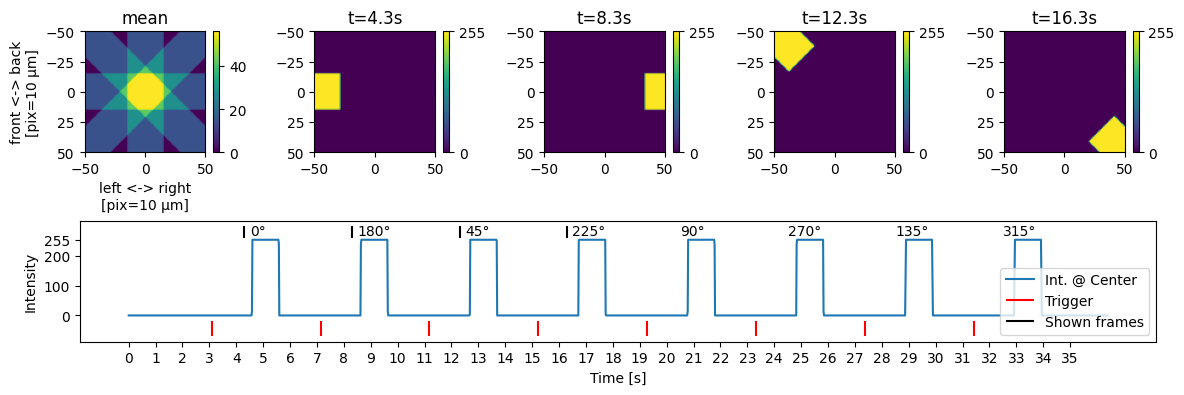

In [28]:
# →, ←, ↘, ↖, ↓, ↑, ↙, ↗
RGC_MovingBar_setup3 = np.flip(bar, axis=1)[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
fig, axs = plot_mb(RGC_MovingBar_setup3, bar_mark, time_bar)
np.save(os.path.join(out_dir, 'RGC_MovingBar_setup3'), RGC_MovingBar_setup3)
plt.savefig(os.path.join(out_dir, 'RGC_MovingBar_setup3.pdf'), bbox_inches='tight')

In [30]:
assert np.all(RGC_MovingBar_setup3.astype(np.uint8) == RGC_MovingBar_setup3)

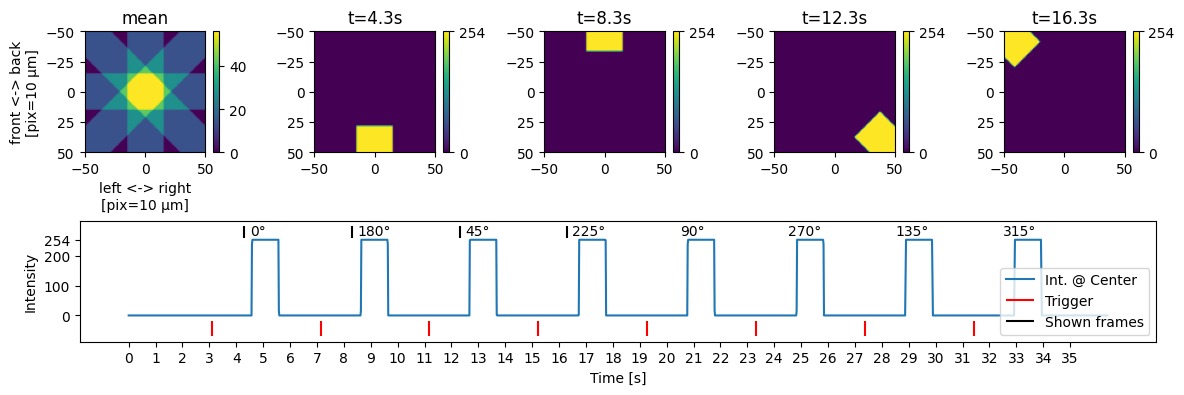

In [17]:
# ↑, ↓, ↖, ↘, ←, →, ↙, ↗
DS_setup1 = np.rot90(bar, k=1, axes=(1, 2))[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
fig, axs = plot_mb(DS_setup1, bar_mark, time_bar)
np.save(os.path.join(out_dir, 'DS_setup1'), DS_setup1)
plt.savefig(os.path.join(out_dir, 'DS_setup1.pdf'), bbox_inches='tight')

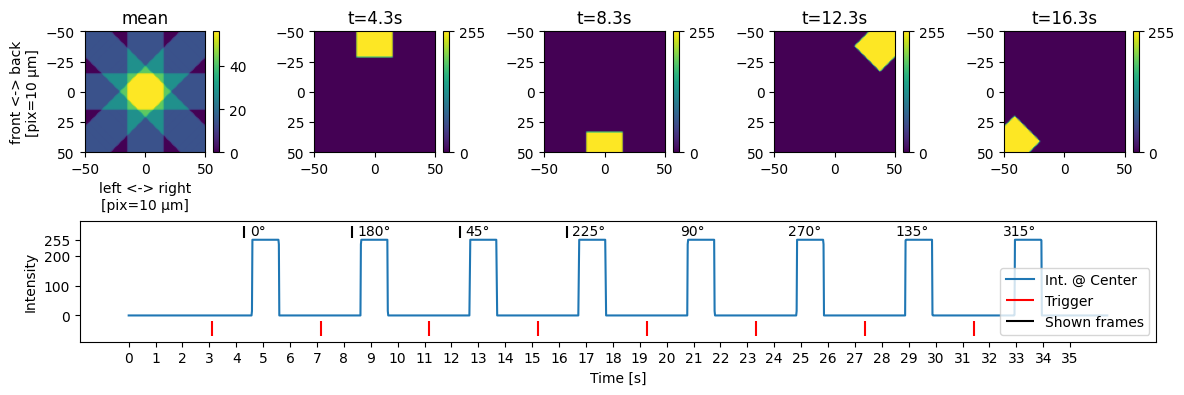

In [31]:
# ↓, ↑, ↙, ↗, ←, →, ↖, ↘
DS_setup3 = np.rot90(np.flip(bar, axis=2), k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
fig, axs = plot_mb(DS_setup3, bar_mark, time_bar)
np.save(os.path.join(out_dir, 'DS_setup3'), DS_setup3)
plt.savefig(os.path.join(out_dir, 'DS_setup3.pdf'), bbox_inches='tight')

In [34]:
assert np.all(DS_setup3.astype(np.uint8) == DS_setup3)

np.savez_compressed(
    os.path.join(out_dir, 'DS_setup3_movie_and_trigger'),
    stimulus=DS_setup3.astype(np.uint8),
    time=time_bar.astype(np.float32),
    trigger=bar_mark,
)

## Chirp

Version "f124bb886d58ff93a1e1d4448d76e979": 'dxStim_um': 1000

Setup 1 - Example users:
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Dominic\\Chirp'
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Tom\\Chirp'
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Ryan\\Chirp'
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Nadine\\Chirp'
- 
Setup 3 - Example users:
- 'C:\\Users\\AGEuler\\Documents\\QDSpy\\Stimuli\\Katrin\\RGCs\\Chirp'

Version "a54b9cb714cb964bbec150c6b2205929": 'dxStim_um': 1000
Notes: Identical to f124bb886d58ff93a1e1d4448d76e979 expect that it enforces the bakground to be reset to black at the beginning.
Setup 1 - Example users:
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Flo\\Chirp'
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Flo\\gratings_V4\\Chirp'

Version "2259330f4015ea49d3dc2d7241d4b43d": 'dxStim_um': 800
Notes: Identical to f124bb886d58ff93a1e1d4448d76e979 expect that it uses 800 instead of 1000 um

Setup 1 - Example users:
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Chenchen\\RGC_Chirp'
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Klaudia\\smaller stim size RGCs\\RGC_Chirp'
- 'C:\\Users\\teuler\\Documents\\QDSpy-experimental\\Stimuli\\Klaudia\\Colored noise\\RGC_Chirp'

Setup 3 - Example users:
- 'C:\\Users\\AGEuler\\Documents\\QDSpy\\Stimuli\\Chenchen\\RGC_Chirp'
- 'C:\\Users\\AGEuler\\Documents\\QDSpy\\Stimuli\\Tom\\RGC_Chirp'
- 'C:\Users\AGEuler\Documents\QDSpy\Stimuli\Klaudia\smaller stim size RGCs\RGC_Chirp.pickle' (edited) 

In [35]:
chirp800_file = 'RGC_Chirp_800um_60Hz_10um_pixels.npy'
chirp800_mark_file = 'RGC_Chirp_800um_60Hz_10um_pixels_mark.npy'

chirp1000_file = 'RGC_Chirp_1000um_60Hz_10um_pixels.npy'
chirp1000_mark_file = 'RGC_Chirp_1000um_60Hz_10um_pixels_mark.npy'

In [36]:
chirp800 = np.load(os.path.join(stim_dir, chirp800_file))
chirp800 = np.round(np.mean(chirp800, axis=-1)).astype(int)
chirp800.shape

(1980, 120, 120)

In [37]:
chirp1000 = np.load(os.path.join(stim_dir, chirp1000_file))
chirp1000 = np.round(np.mean(chirp1000, axis=-1)).astype(int)
chirp1000.shape

(1980, 120, 120)

In [38]:
chirp_mark = np.load(os.path.join(stim_dir, chirp800_mark_file))
chirp_mark = np.append(chirp_mark[:-1] & (~chirp_mark[1:]), False)
chirp_mark

array([False, False,  True, ..., False, False, False])

In [39]:
time_chirp = np.arange(chirp800.shape[0]) * 1./60.

In [40]:
np.save(os.path.join(out_dir, 'chirp_trigger'), chirp_mark)
np.save(os.path.join(out_dir, 'chirp_time_s'), time_chirp)

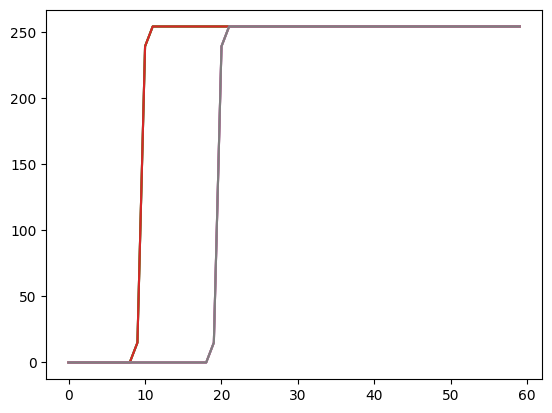

In [41]:
# Checking that the chirp is centered correctly

plt.plot(chirp1000[60*3, 60:, 60][::-1])
plt.plot(chirp1000[60*3, :60, 60])
plt.plot(chirp1000[60*3, 60, 60:][::-1])
plt.plot(chirp1000[60*3, 60, :60])

plt.plot(chirp800[60*3, 60:, 60][::-1])
plt.plot(chirp800[60*3, :60, 60])
plt.plot(chirp800[60*3, 60, 60:][::-1])
plt.plot(chirp800[60*3, 60, :60])

plt.show()

In [42]:
def plot_chirp(chirp, chirp_mark, chirp_time):
    fig, axs = plt.subplots(1, 2, figsize=(12, 2), width_ratios=(1, 3))

    t_s = 3
    
    ax = axs[0]
    h, w = chirp.shape[1:3]
    im = ax.imshow(chirp[60*t_s], vmin=0, vmax=254, extent=(-w/2, w/2, h/2, -h/2))
    plt.colorbar(im, ax=ax, ticks=[0, 254])
    ax.set(xlabel='left <-> right\n[pix=10 µm]', ylabel='front <-> back\n[pix=10 µm]', title=f't={t_s}s')
    
    ax = axs[1]
    ax.plot(chirp_time, chirp[:, chirp.shape[1]//2, chirp.shape[2]//2], label='Int. @ Center')
    ax.vlines(chirp_time[chirp_mark], -70, -20, color='r', label='Trigger')
    ax.set(xlabel='Time [s]', ylabel='Intensity')
    ax.set_yticks([0, 100, 200, 254])
    ax.set_xticks([0, 2, 5, 8, 10, 18, 20, 28, 30, 33])
    ax.legend(loc='upper right')
    
    return fig, axs

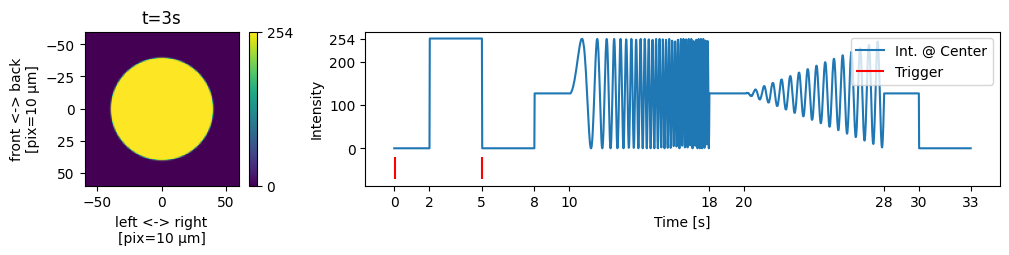

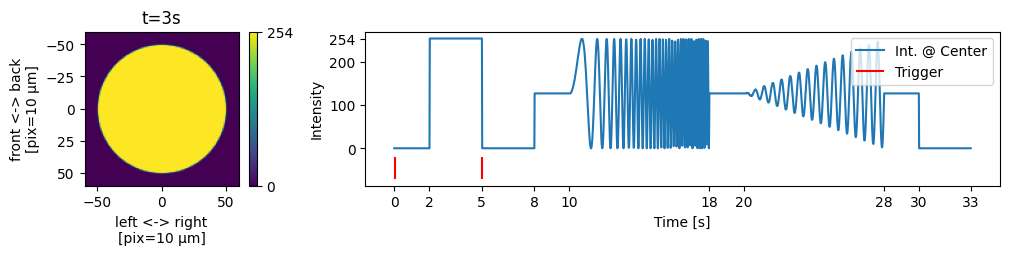

In [43]:
plot_chirp(chirp800, chirp_mark, time_chirp);
plot_chirp(chirp1000, chirp_mark, time_chirp);

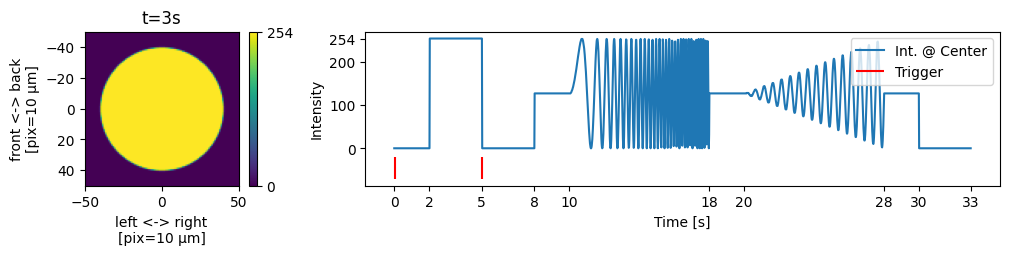

In [44]:
chirp800_setup1 = chirp800[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
fig, axs = plot_chirp(chirp800_setup1, chirp_mark, time_chirp)
np.save(os.path.join(out_dir, 'chirp800_setup1'), chirp800_setup1)
plt.savefig(os.path.join(out_dir, 'chirp800_setup1.pdf'), bbox_inches='tight')

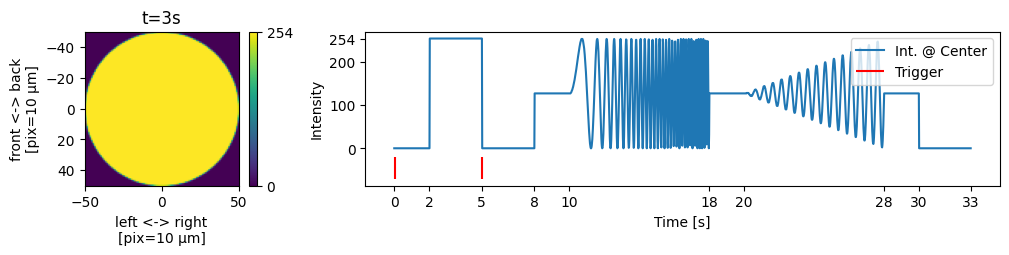

In [45]:
chirp1000_setup1 = chirp1000[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
fig, axs = plot_chirp(chirp1000_setup1, chirp_mark, time_chirp)
np.save(os.path.join(out_dir, 'chirp1000_setup1'), chirp1000_setup1)
plt.savefig(os.path.join(out_dir, 'chirp1000_setup1.pdf'), bbox_inches='tight')

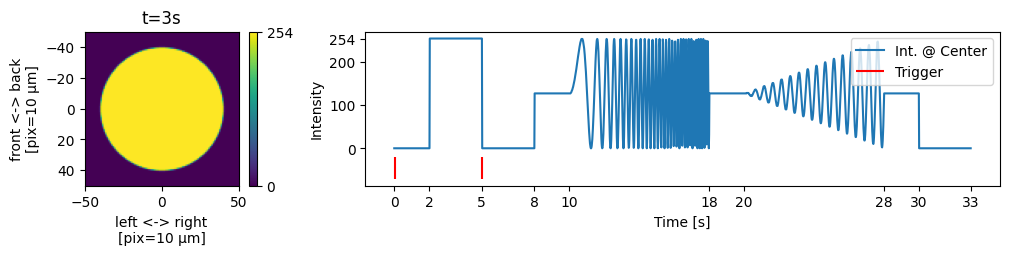

In [46]:
chirp800_setup3 = chirp800[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
fig, axs = plot_chirp(chirp800_setup3, chirp_mark, time_chirp)
np.save(os.path.join(out_dir, 'chirp800_setup3'), chirp800_setup3)
plt.savefig(os.path.join(out_dir, 'chirp800_setup3.pdf'), bbox_inches='tight')

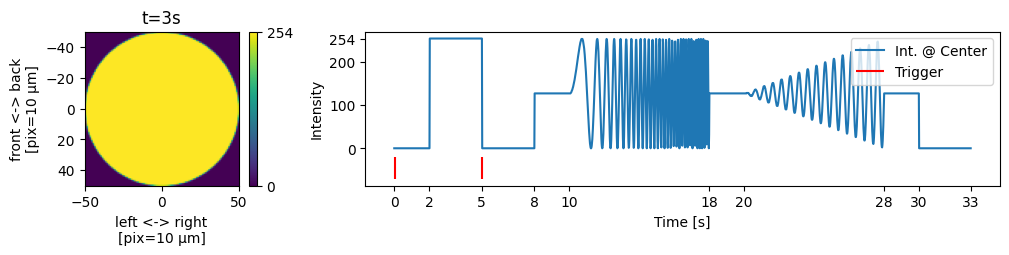

In [47]:
chirp1000_setup3 = chirp1000[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
fig, axs = plot_chirp(chirp1000_setup3, chirp_mark, time_chirp)
np.save(os.path.join(out_dir, 'chirp1000_setup3'), chirp1000_setup3)
plt.savefig(os.path.join(out_dir, 'chirp1000_setup3.pdf'), bbox_inches='tight')

In [48]:
assert np.all(chirp1000_setup3.astype(np.uint8) == chirp1000_setup3)

np.savez_compressed(
    os.path.join(out_dir, 'chirp1000_setup3_movie_and_trigger'),
    stimulus=chirp1000_setup3.astype(np.uint8),
    time=time_chirp.astype(np.float32),
    trigger=chirp_mark,
)

# Copy files

In [32]:
copy_dir = "/gpfs01/euler/data/Resources/Stimulus/All-GCL/"
os.listdir(copy_dir)

['RGC_MovingBar_setup3.pdf',
 'chirp800_setup3.pdf',
 'bar_trigger.npy',
 'chirp1000_setup3.npy',
 'chirp_time_s.npy',
 'chirp800_setup1.npy',
 'DS_setup1.pdf',
 'chirp1000_setup1.npy',
 'RGC_MovingBar_setup1.pdf',
 'bar_time_s.npy',
 'DS_setup3.pdf',
 'chirp1000_setup3.pdf',
 'DS_setup1.npy',
 'chirp800_setup3.npy',
 'chirp1000_setup1.pdf',
 'chirp_trigger.npy',
 'DS_setup3.npy',
 'chirp800_setup1.pdf',
 'RGC_MovingBar_setup1.npy',
 'RGC_MovingBar_setup3.npy']

In [44]:
import shutil

shutil.copytree(out_dir, copy_dir, dirs_exist_ok=True)

'/gpfs01/euler/data/Resources/Stimulus/All-GCL/'